<div align="center">

# 🏠 **House Price Prediction & Property Segmentation**

### Machine Learning Analysis of House Prices, Property Characteristics, and Market Segments


<img src="https://i.postimg.cc/52Mj9zVT/Chat-GPT-Image-Sep-19-2026-04-48-38-PM.png"
width="800">

</div>

---

## **📌 Project Overview**

This project focuses on analyzing a housing dataset and applying Machine Learning techniques to understand property characteristics, predict house prices, and identify meaningful groups of properties.

The analysis explores factors such as property size, quality, number of rooms, construction details, location-related attributes, and other features associated with house prices.

The project combines **Exploratory Data Analysis (EDA)** with **Supervised and Unsupervised Machine Learning techniques** to uncover patterns, relationships, property segments, and unusual observations within the dataset.

---

## **🎯 Objectives**

* Understand the structure and characteristics of the housing dataset.
* Perform data quality checks and data cleaning.
* Analyze missing values and duplicate records.
* Perform univariate, bivariate, and multivariate analysis.
* Study the distribution of numerical and categorical variables.
* Analyze the relationship between property features and house prices.
* Perform correlation analysis among numerical variables.
* Apply Regression to predict house prices.
* Evaluate regression models using appropriate performance metrics.
* Apply K-Means Clustering to segment properties based on their characteristics.
* Apply DBSCAN Clustering to identify density-based property groups and potential outliers.
* Compare and interpret the results obtained from different Machine Learning techniques.

---

## **📊 Dataset**

The dataset contains information about residential properties and their sale prices.

It includes features related to:

Property Area, Overall Quality, Bedrooms, Bathrooms, Rooms, Garage, Basement, Year Built, Property Condition, Neighborhood, Sale Price, and other property characteristics.

The target variable for the regression task is SalePrice, which represents the selling price of the property.

---

## **🛠️ Tools & Technologies**

* Python
* Pandas
* NumPy
* Matplotlib
* Seaborn
* SciPy
* Scikit-learn
* Google Colab

---

## **🤖 Machine Learning Techniques**

### **1. Regression**

Used to predict the **SalePrice** of a property based on its characteristics.

### **2. K-Means Clustering**

Used to group properties with similar characteristics into meaningful segments.

### **3. DBSCAN Clustering**

Used to identify density-based property groups and detect unusual or isolated observations.

---

## **📈 Expected Outcome**

The project aims to understand the factors associated with house prices, develop a model for predicting property prices, and identify meaningful property segments using clustering techniques.

The analysis demonstrates practical skills in data cleaning, exploratory data analysis, feature engineering, data preprocessing, regression, clustering, model evaluation, and data visualization.


In [1]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load the CSV

df = pd.read_csv('/AmesHousing.csv')

**3.Dataset** **Understanding**

In [3]:
# Check the dataset
df.shape

(2930, 82)

In [4]:
df.head()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   object 
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   object 
 7   Alley            198 non-null    object 
 8   Lot Shape        2930 non-null   object 
 9   Land Contour     2930 non-null   object 
 10  Utilities        2930 non-null   object 
 11  Lot Config       2930 non-null   object 
 12  Land Slope       2930 non-null   object 
 13  Neighborhood     2930 non-null   object 
 14  Condition 1      2930 non-null   object 
 15  Condition 2      2930 non-null   object 
 16  Bldg Type        2930 non-null   object 
 17  House Style   

In [6]:
df.columns

Index(['Order', 'PID', 'MS SubClass', 'MS Zoning', 'Lot Frontage', 'Lot Area',
       'Street', 'Alley', 'Lot Shape', 'Land Contour', 'Utilities',
       'Lot Config', 'Land Slope', 'Neighborhood', 'Condition 1',
       'Condition 2', 'Bldg Type', 'House Style', 'Overall Qual',
       'Overall Cond', 'Year Built', 'Year Remod/Add', 'Roof Style',
       'Roof Matl', 'Exterior 1st', 'Exterior 2nd', 'Mas Vnr Type',
       'Mas Vnr Area', 'Exter Qual', 'Exter Cond', 'Foundation', 'Bsmt Qual',
       'Bsmt Cond', 'Bsmt Exposure', 'BsmtFin Type 1', 'BsmtFin SF 1',
       'BsmtFin Type 2', 'BsmtFin SF 2', 'Bsmt Unf SF', 'Total Bsmt SF',
       'Heating', 'Heating QC', 'Central Air', 'Electrical', '1st Flr SF',
       '2nd Flr SF', 'Low Qual Fin SF', 'Gr Liv Area', 'Bsmt Full Bath',
       'Bsmt Half Bath', 'Full Bath', 'Half Bath', 'Bedroom AbvGr',
       'Kitchen AbvGr', 'Kitchen Qual', 'TotRms AbvGrd', 'Functional',
       'Fireplaces', 'Fireplace Qu', 'Garage Type', 'Garage Yr Blt',
      

In [7]:
df.describe()

,Order,PID,MS SubClass,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,...,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,SalePrice
count,2930.00000,2.930000e+03,2930.000000,2440.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2907.000000,...,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000
mean,1465.50000,7.144645e+08,57.387372,69.224590,10147.921843,6.094881,5.563140,1971.356314,1984.266553,101.896801,...,93.751877,47.533447,23.011604,2.592491,16.002048,2.243345,50.635154,6.216041,2007.790444,180796.060068
std,845.96247,1.887308e+08,42.638025,23.365335,7880.017759,1.411026,1.111537,30.245361,20.860286,179.112611,...,126.361562,67.483400,64.139059,25.141331,56.087370,35.597181,566.344288,2.714492,1.316613,79886.692357
min,1.00000,5.263011e+08,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,12789.000000
25%,733.25000,5.284770e+08,20.000000,58.000000,7440.250000,5.000000,5.000000,1954.000000,1965.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,2007.000000,129500.000000
50%,1465.50000,5.354536e+08,50.000000,68.000000,9436.500000,6.000000,5.000000,1973.000000,1993.000000,0.000000,...,0.000000,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,160000.000000
75%,2197.75000,9.071811e+08,70.000000,80.000000,11555.250000,7.000000,6.000000,2001.000000,2004.000000,164.000000,...,168.000000,70.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,213500.000000
max,2930.00000,1.007100e+09,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,...,1424.000000,742.000000,1012.000000,508.000000,576.000000,800.000000,17000.000000,12.000000,2010.000000,755000.000000


In [8]:
# Make Pandas display all columns
pd.set_option('display.max_columns', None)

In [9]:
df.head()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,Land Slope,Neighborhood,Condition 1,Condition 2,Bldg Type,House Style,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Roof Style,Roof Matl,Exterior 1st,Exterior 2nd,Mas Vnr Type,Mas Vnr Area,Exter Qual,Exter Cond,Foundation,Bsmt Qual,Bsmt Cond,Bsmt Exposure,BsmtFin Type 1,BsmtFin SF 1,BsmtFin Type 2,BsmtFin SF 2,Bsmt Unf SF,Total Bsmt SF,Heating,Heating QC,Central Air,Electrical,1st Flr SF,2nd Flr SF,Low Qual Fin SF,Gr Liv Area,Bsmt Full Bath,Bsmt Half Bath,Full Bath,Half Bath,Bedroom AbvGr,Kitchen AbvGr,Kitchen Qual,TotRms AbvGrd,Functional,Fireplaces,Fireplace Qu,Garage Type,Garage Yr Blt,Garage Finish,Garage Cars,Garage Area,Garage Qual,Garage Cond,Paved Drive,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,5,1960,1960,Hip,CompShg,BrkFace,Plywood,Stone,112.0,TA,TA,CBlock,TA,Gd,Gd,BLQ,639.0,Unf,0.0,441.0,1080.0,GasA,Fa,Y,SBrkr,1656,0,0,1656,1.0,0.0,1,0,3,1,TA,7,Typ,2,Gd,Attchd,1960.0,Fin,2.0,528.0,TA,TA,P,210,62,0,0,0,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Feedr,Norm,1Fam,1Story,5,6,1961,1961,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,CBlock,TA,TA,No,Rec,468.0,LwQ,144.0,270.0,882.0,GasA,TA,Y,SBrkr,896,0,0,896,0.0,0.0,1,0,2,1,TA,5,Typ,0,NaN,Attchd,1961.0,Unf,1.0,730.0,TA,TA,Y,140,0,0,0,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,6,1958,1958,Hip,CompShg,Wd Sdng,Wd Sdng,BrkFace,108.0,TA,TA,CBlock,TA,TA,No,ALQ,923.0,Unf,0.0,406.0,1329.0,GasA,TA,Y,SBrkr,1329,0,0,1329,0.0,0.0,1,1,3,1,Gd,6,Typ,0,NaN,Attchd,1958.0,Unf,1.0,312.0,TA,TA,Y,393,36,0,0,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,7,5,1968,1968,Hip,CompShg,BrkFace,BrkFace,NaN,0.0,Gd,TA,CBlock,TA,TA,No,ALQ,1065.0,Unf,0.0,1045.0,2110.0,GasA,Ex,Y,SBrkr,2110,0,0,2110,1.0,0.0,2,1,3,1,Ex,8,Typ,2,TA,Attchd,1968.0,Fin,2.0,522.0,TA,TA,Y,0,0,0,0,0,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,5,5,1997,1998,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,PConc,Gd,TA,No,GLQ,791.0,Unf,0.0,137.0,928.0,GasA,Gd,Y,SBrkr,928,701,0,1629,0.0,0.0,2,1,3,1,TA,6,Typ,1,TA,Attchd,1997.0,Fin,2.0,482.0,TA,TA,Y,212,34,0,0,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


**4.Duplicate Check**

In [10]:
df.duplicated().sum()

np.int64(0)

**5.Initial Missing Value Analysis**

In [11]:
# To find the missing values

missing_df = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing Percentage': (df.isnull().sum() / len(df)) * 100
})

missing_df = missing_df[missing_df['Missing Count'] > 0]
missing_df = missing_df.sort_values('Missing Count', ascending=False)

missing_df

,Missing Count,Missing Percentage
Pool QC,2917,99.556314
Misc Feature,2824,96.382253
Alley,2732,93.242321
Fence,2358,80.477816
Mas Vnr Type,1775,60.580205
Fireplace Qu,1422,48.532423
Lot Frontage,490,16.723549
Garage Qual,159,5.426621
Garage Cond,159,5.426621
Garage Yr Blt,159,5.426621


**6.Missing Value Handling**

In [12]:
# Data Cleaning
# the categorical columns where missing means "feature not present."

none_cols = [
    'Pool QC',
    'Misc Feature',
    'Alley',
    'Fence',
    'Fireplace Qu',
    'Garage Qual',
    'Garage Cond',
    'Garage Finish',
    'Garage Type',
    'Bsmt Exposure',
    'BsmtFin Type 1',
    'BsmtFin Type 2',
    'Bsmt Cond',
    'Bsmt Qual'
]

df[none_cols] = df[none_cols].fillna('None')

In [13]:
df[none_cols].isnull().sum()

,0
Pool QC,0
Misc Feature,0
Alley,0
Fence,0
Fireplace Qu,0
Garage Qual,0
Garage Cond,0
Garage Finish,0
Garage Type,0
Bsmt Exposure,0


In [14]:
# Checking Remaining Missing Values

missing_num = df.isnull().sum()

missing_num[missing_num > 0].sort_values(ascending=False)

,0
Mas Vnr Type,1775
Lot Frontage,490
Garage Yr Blt,159
Mas Vnr Area,23
Bsmt Full Bath,2
Bsmt Half Bath,2
BsmtFin SF 1,1
BsmtFin SF 2,1
Bsmt Unf SF,1
Electrical,1


In [15]:
# Handling Missing Values in Mas Vnr Type

df['Mas Vnr Type'] = df['Mas Vnr Type'].fillna('None')

In [16]:
df['Mas Vnr Type'].isnull().sum()

np.int64(0)

In [17]:
# Handling Missing Values in Lot Frontage

df['Lot Frontage'] = df['Lot Frontage'].fillna(df['Lot Frontage'].median())

In [18]:
df['Lot Frontage'].isnull().sum()

np.int64(0)

In [19]:
# Handling Missing Values in Garage Yr Blt

df['Garage Yr Blt'] = df['Garage Yr Blt'].fillna(df['Year Built'])

In [20]:
df['Garage Yr Blt'].isnull().sum()

np.int64(0)

In [21]:
# Handling Missing Values in Mas Vnr Area

df['Mas Vnr Area'] = df['Mas Vnr Area'].fillna(df['Mas Vnr Area'].median())

In [22]:
df['Mas Vnr Area'].isnull().sum()

np.int64(0)

In [23]:
# Handling Missing Values in Bsmt Full Bath

df['Bsmt Full Bath'] = df['Bsmt Full Bath'].fillna(df['Bsmt Full Bath'].median())

In [24]:
df['Bsmt Full Bath'].isnull().sum()

np.int64(0)

In [25]:
# Handling Missing Values in Bsmt Half Bath

df['Bsmt Half Bath'] = df['Bsmt Half Bath'].fillna(df['Bsmt Half Bath'].median())

In [26]:
df['Bsmt Full Bath'].isnull().sum()

np.int64(0)

In [27]:
# Handling Missing Values in Bsmt Half Bath

df['Bsmt Half Bath'] = df['Bsmt Half Bath'].fillna(df['Bsmt Half Bath'].median())

In [28]:
df['Bsmt Half Bath'].isnull().sum()

np.int64(0)

In [29]:
# Handling Missing Values in BsmtFin SF 1

df['BsmtFin SF 1'] = df['BsmtFin SF 1'].fillna(df['BsmtFin SF 1'].median())

In [30]:
df['BsmtFin SF 1'].isnull().sum()

np.int64(0)

In [31]:
# Handling Missing Values in BsmtFin SF 2

df['BsmtFin SF 2'] = df['BsmtFin SF 2'].fillna(df['BsmtFin SF 2'].median())

In [32]:
df['BsmtFin SF 2'].isnull().sum()

np.int64(0)

In [33]:
# Handling Missing Values in Bsmt Unf SF

df['Bsmt Unf SF'] = df['Bsmt Unf SF'].fillna(df['Bsmt Unf SF'].median())

In [34]:
df['Bsmt Unf SF'].isnull().sum()

np.int64(0)

In [35]:
# Handling Missing Values in Electrical

df['Electrical'] = df['Electrical'].fillna(df['Electrical'].mode()[0])

In [36]:
df['Electrical'].isnull().sum()

np.int64(0)

In [37]:
# Handling Missing Values in Total Bsmt SF

df['Total Bsmt SF'] = df['Total Bsmt SF'].fillna(df['Total Bsmt SF'].median())

In [38]:
df['Total Bsmt SF'].isnull().sum()

np.int64(0)

In [39]:
# Handling Missing Values in Garage Cars

df['Garage Cars'] = df['Garage Cars'].fillna(df['Garage Cars'].median())

In [40]:
df['Garage Cars'].isnull().sum()

np.int64(0)

In [41]:
# Handling Missing Values in Garage Area

df['Garage Area'] = df['Garage Area'].fillna(df['Garage Area'].median())

In [42]:
df['Garage Area'].isnull().sum()

np.int64(0)

In [43]:
# Final Missing Value Check

missing_num = df.isnull().sum()

missing_num[missing_num > 0].sort_values(ascending=False)

,0


**7.Exploratory Data Analysis**

Univariate Analysis --> SalePrice


In [44]:
# SalePrice - Basic Statistical Summary

df['SalePrice'].describe()

,SalePrice
count,2930.000000
mean,180796.060068
std,79886.692357
min,12789.000000
25%,129500.000000
50%,160000.000000
75%,213500.000000
max,755000.000000


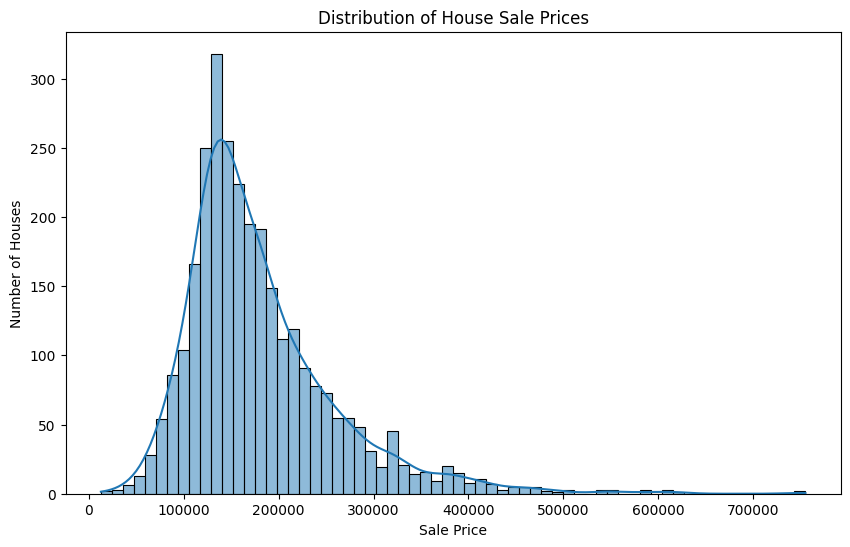

In [45]:
# SalePrice Distribution

plt.figure(figsize=(10, 6))

sns.histplot(df['SalePrice'], kde=True)

plt.title('Distribution of House Sale Prices')
plt.xlabel('Sale Price')
plt.ylabel('Number of Houses')

plt.show()

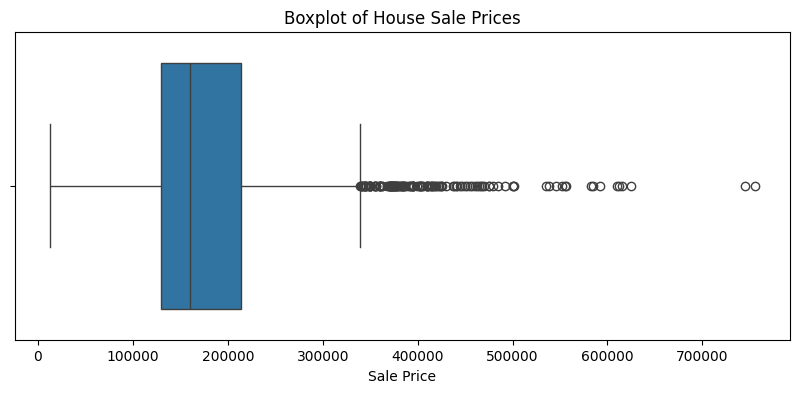

In [46]:
# SalePrice Boxplot

plt.figure(figsize=(10, 4))

sns.boxplot(x=df['SalePrice'])

plt.title('Boxplot of House Sale Prices')
plt.xlabel('Sale Price')

plt.show()

Univariate Analysis --> Numerical Feature Analysis

In [47]:
# Checking Numerical Columns

numerical_cols = df.select_dtypes(include=np.number).columns

numerical_cols

Index(['Order', 'PID', 'MS SubClass', 'Lot Frontage', 'Lot Area',
       'Overall Qual', 'Overall Cond', 'Year Built', 'Year Remod/Add',
       'Mas Vnr Area', 'BsmtFin SF 1', 'BsmtFin SF 2', 'Bsmt Unf SF',
       'Total Bsmt SF', '1st Flr SF', '2nd Flr SF', 'Low Qual Fin SF',
       'Gr Liv Area', 'Bsmt Full Bath', 'Bsmt Half Bath', 'Full Bath',
       'Half Bath', 'Bedroom AbvGr', 'Kitchen AbvGr', 'TotRms AbvGrd',
       'Fireplaces', 'Garage Yr Blt', 'Garage Cars', 'Garage Area',
       'Wood Deck SF', 'Open Porch SF', 'Enclosed Porch', '3Ssn Porch',
       'Screen Porch', 'Pool Area', 'Misc Val', 'Mo Sold', 'Yr Sold',
       'SalePrice'],
      dtype='object')

In [48]:
# Selecting Important Numerical Features for EDA

important_num_cols = [
    'Lot Frontage',
    'Lot Area',
    'Overall Qual',
    'Overall Cond',
    'Year Built',
    'Year Remod/Add',
    'Total Bsmt SF',
    '1st Flr SF',
    '2nd Flr SF',
    'Gr Liv Area',
    'Full Bath',
    'Half Bath',
    'Bedroom AbvGr',
    'TotRms AbvGrd',
    'Fireplaces',
    'Garage Cars',
    'Garage Area',
    'Wood Deck SF',
    'Open Porch SF'
]

len(important_num_cols)

19

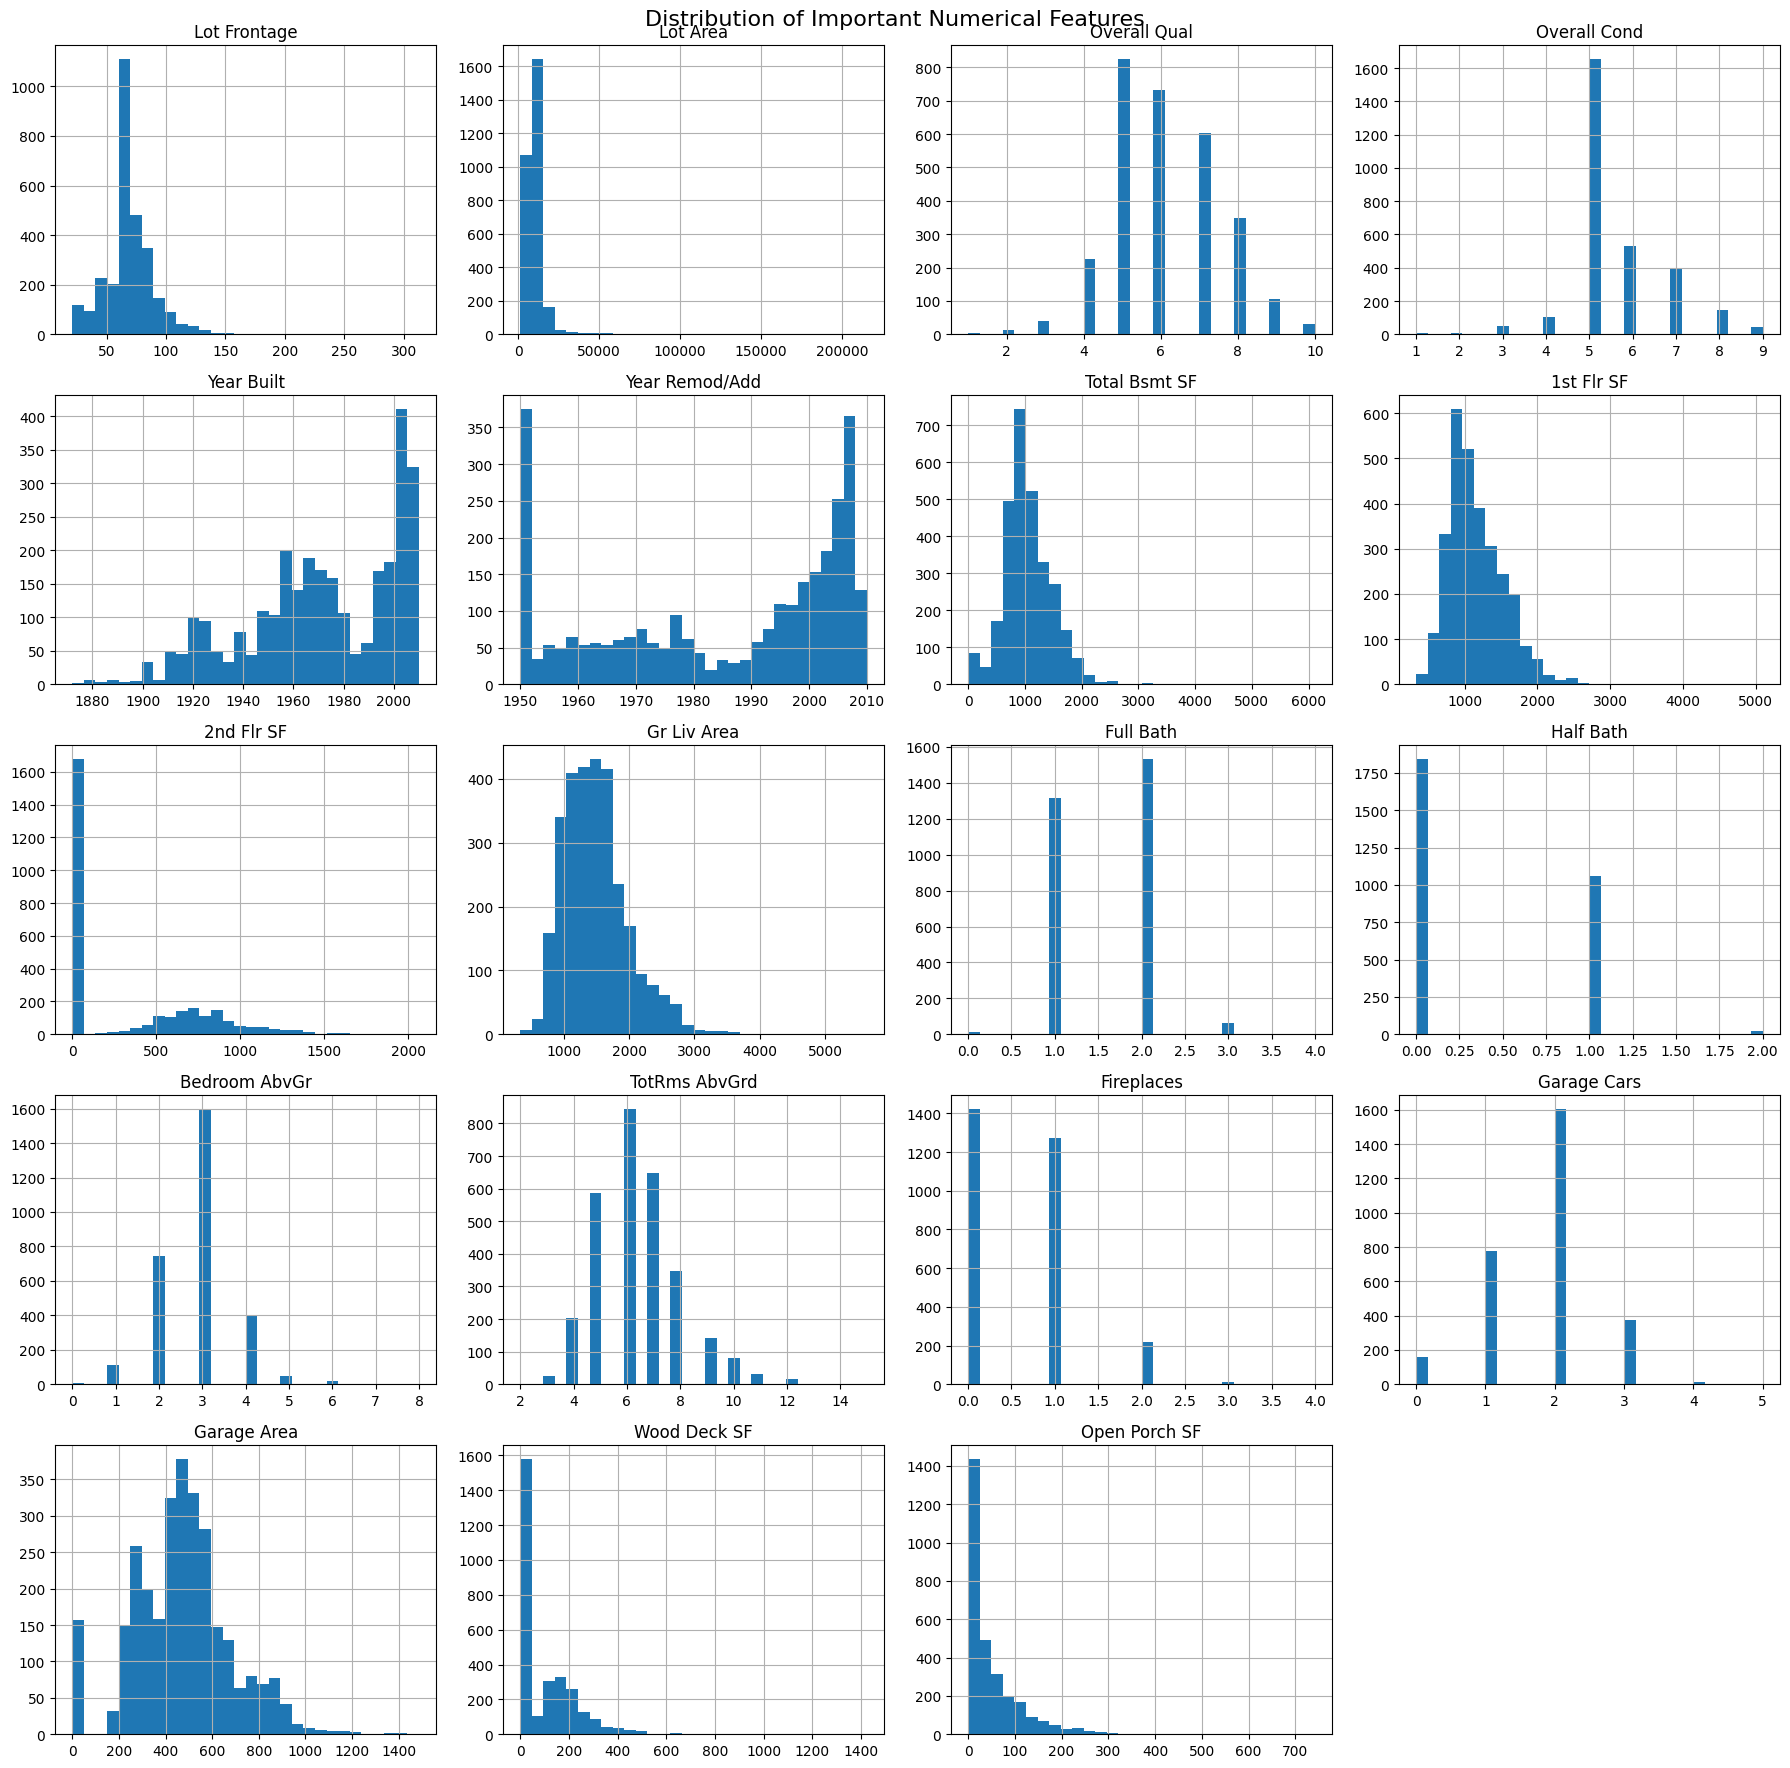

In [49]:
# Distribution of Important Numerical Features

df[important_num_cols].hist(
    figsize=(18, 18),
    bins=30
)

plt.suptitle(
    'Distribution of Important Numerical Features',
    fontsize=16
)

plt.tight_layout()
plt.show()

Univariate Analysis -->Categorical Feature Analysis

In [50]:
# Checking Categorical Columns

categorical_cols = df.select_dtypes(include='object').columns

categorical_cols

Index(['MS Zoning', 'Street', 'Alley', 'Lot Shape', 'Land Contour',
       'Utilities', 'Lot Config', 'Land Slope', 'Neighborhood', 'Condition 1',
       'Condition 2', 'Bldg Type', 'House Style', 'Roof Style', 'Roof Matl',
       'Exterior 1st', 'Exterior 2nd', 'Mas Vnr Type', 'Exter Qual',
       'Exter Cond', 'Foundation', 'Bsmt Qual', 'Bsmt Cond', 'Bsmt Exposure',
       'BsmtFin Type 1', 'BsmtFin Type 2', 'Heating', 'Heating QC',
       'Central Air', 'Electrical', 'Kitchen Qual', 'Functional',
       'Fireplace Qu', 'Garage Type', 'Garage Finish', 'Garage Qual',
       'Garage Cond', 'Paved Drive', 'Pool QC', 'Fence', 'Misc Feature',
       'Sale Type', 'Sale Condition'],
      dtype='object')

In [51]:
# Selecting Important Categorical Features for EDA

important_cat_cols = [
    'MS Zoning',
    'Neighborhood',
    'House Style',
    'Exter Qual',
    'Kitchen Qual',
    'Bsmt Qual',
    'Garage Type',
    'Garage Finish',
    'Central Air',
    'Foundation',
    'Sale Condition'
]

len(important_cat_cols)

11

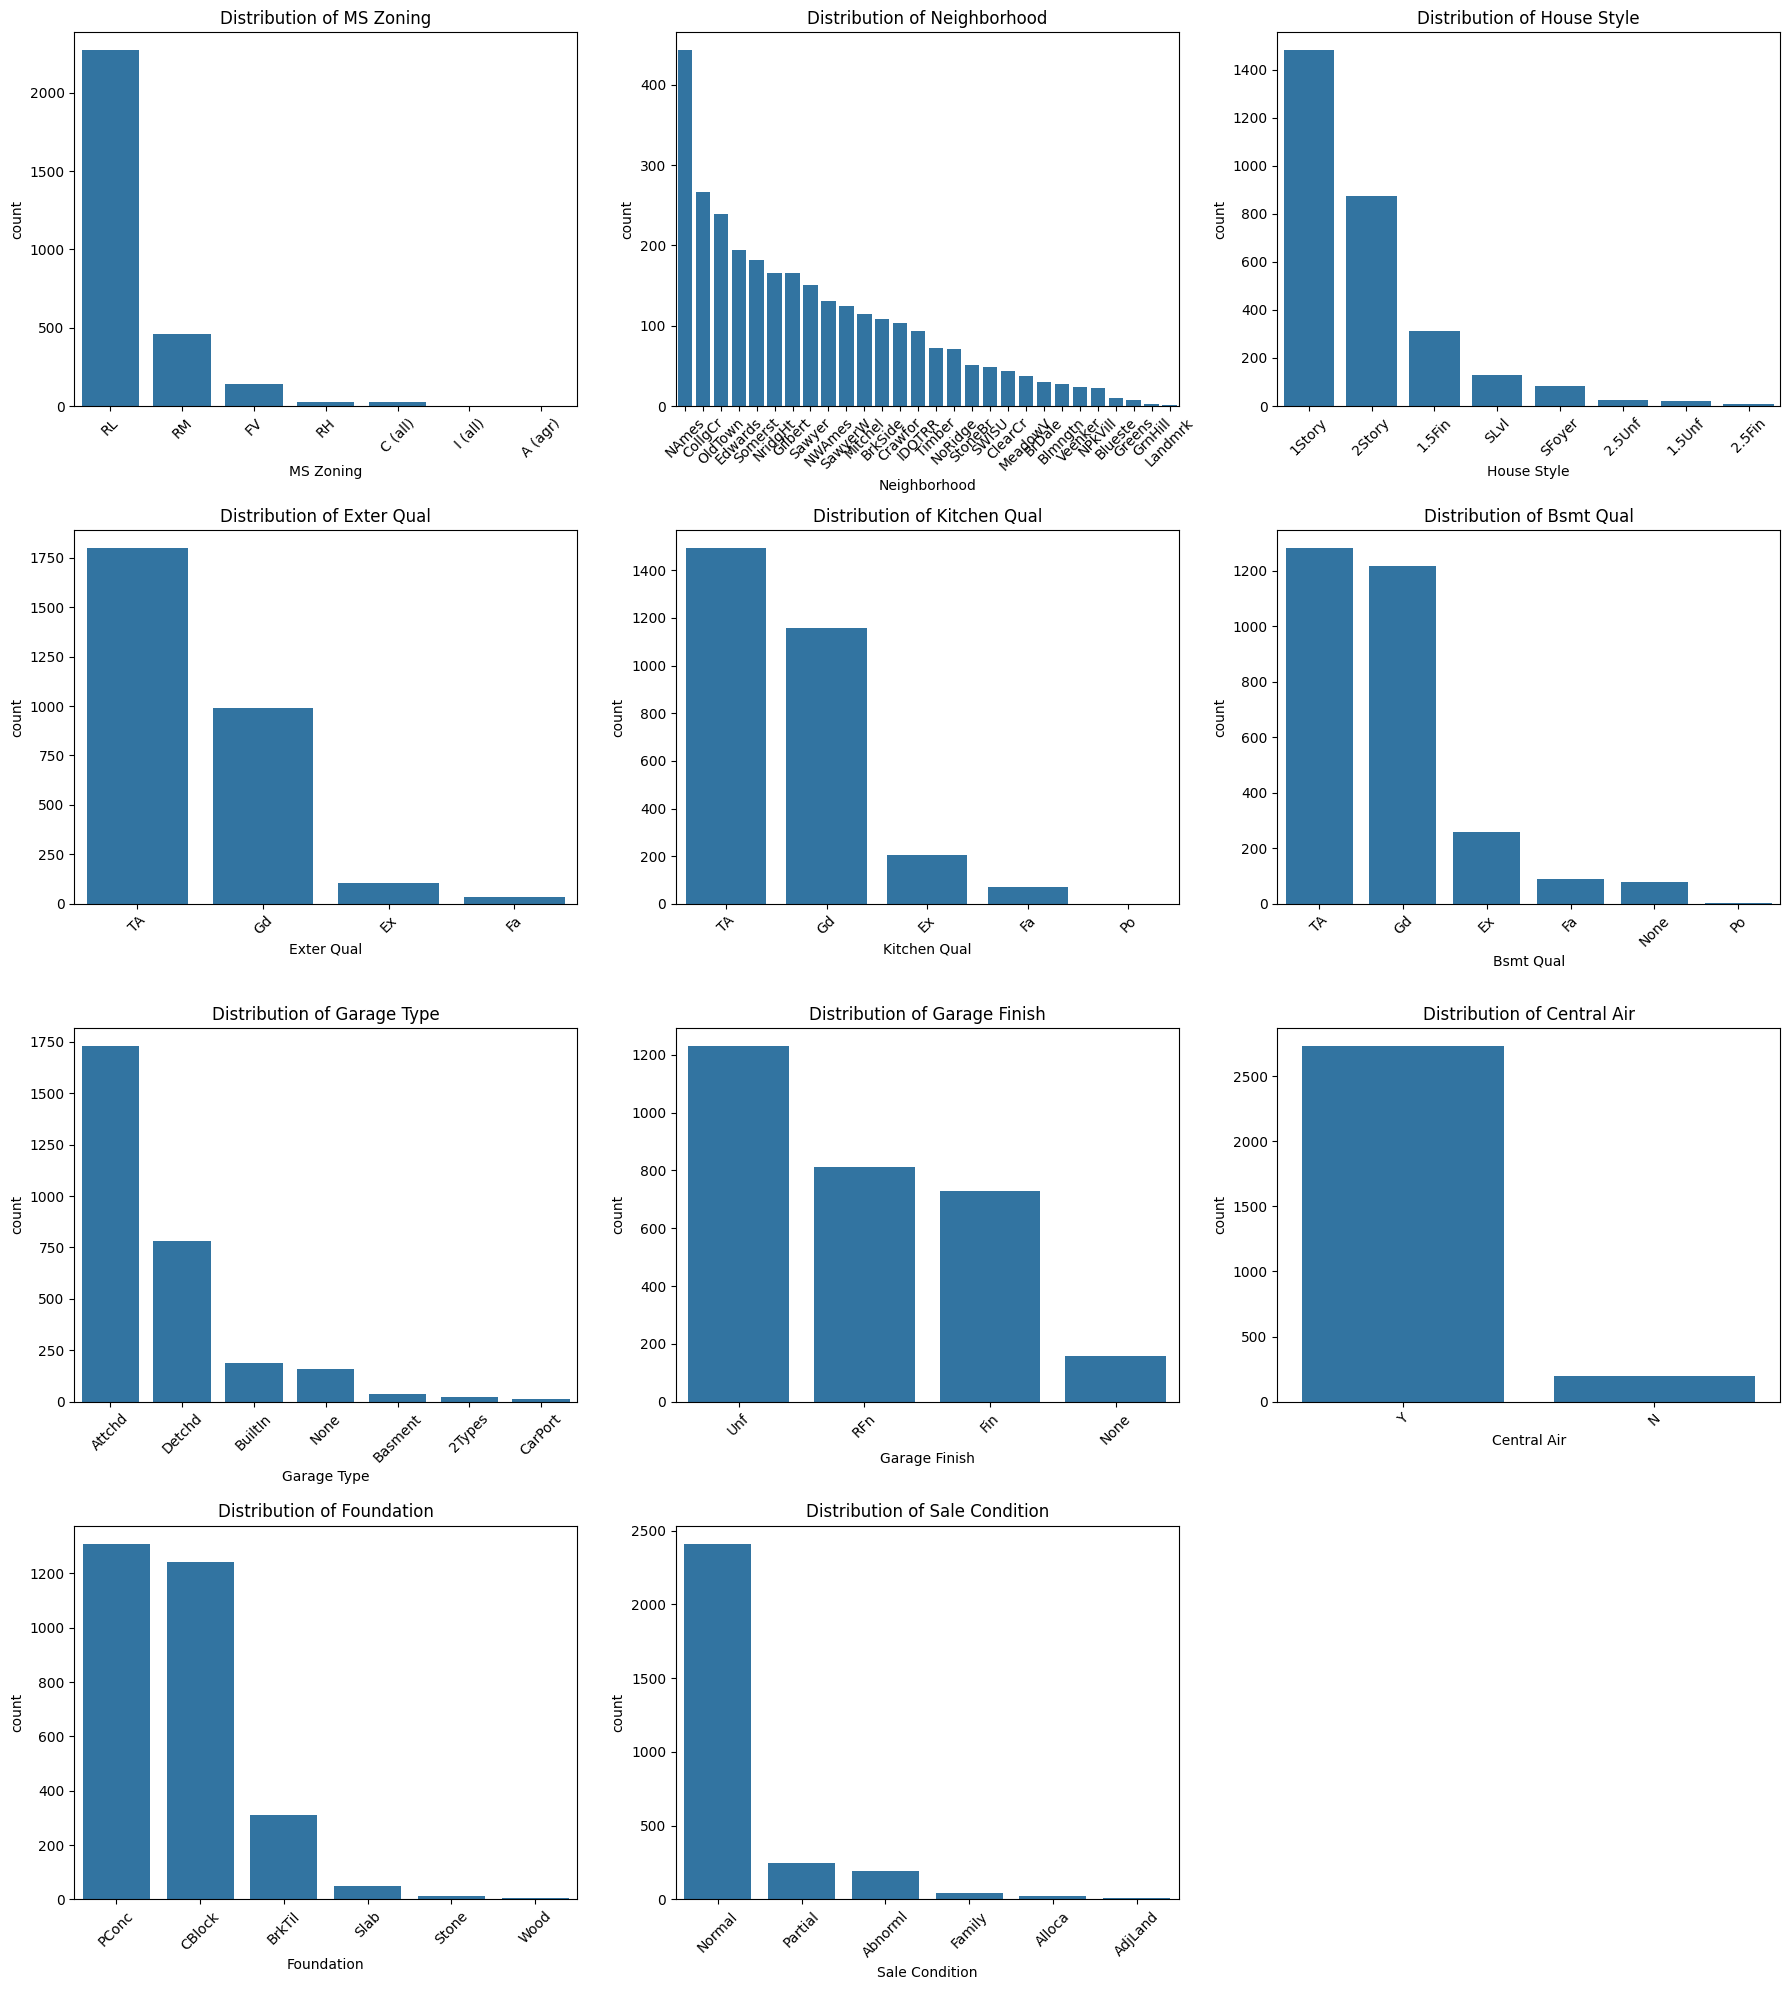

In [52]:
# Distribution of Important Categorical Features

fig, axes = plt.subplots(4, 3, figsize=(18, 20))

for ax, col in zip(axes.flatten(), important_cat_cols):
    sns.countplot(
        data=df,
        x=col,
        ax=ax,
        order=df[col].value_counts().index
    )

    ax.set_title(f'Distribution of {col}')
    ax.tick_params(axis='x', rotation=45)

# Hide unused subplot
axes.flatten()[-1].set_visible(False)

plt.tight_layout()
plt.show()

**Bivariate Analysis**

Bivariate Analysis-->Numerical Feature vs SalePrice

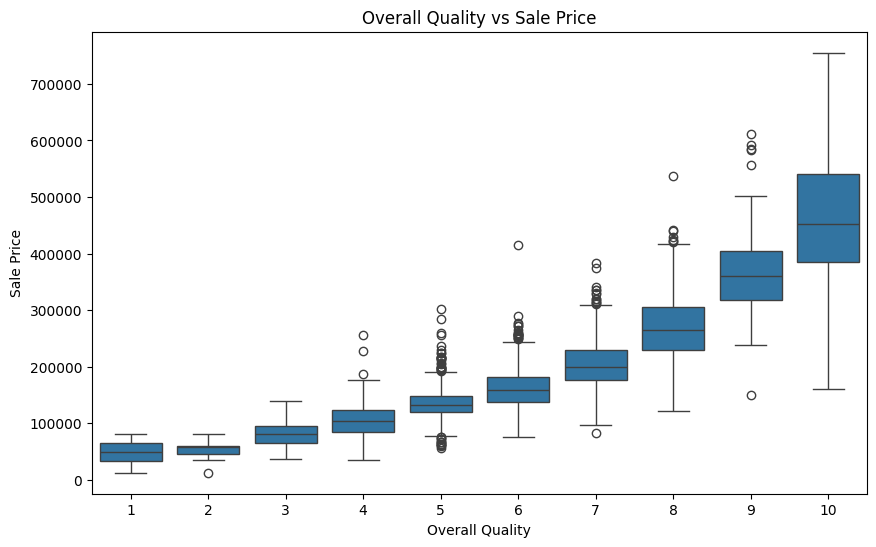

In [53]:
# Overall Quality vs SalePrice

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x='Overall Qual',
    y='SalePrice'
)

plt.title('Overall Quality vs Sale Price')
plt.xlabel('Overall Quality')
plt.ylabel('Sale Price')

plt.show()

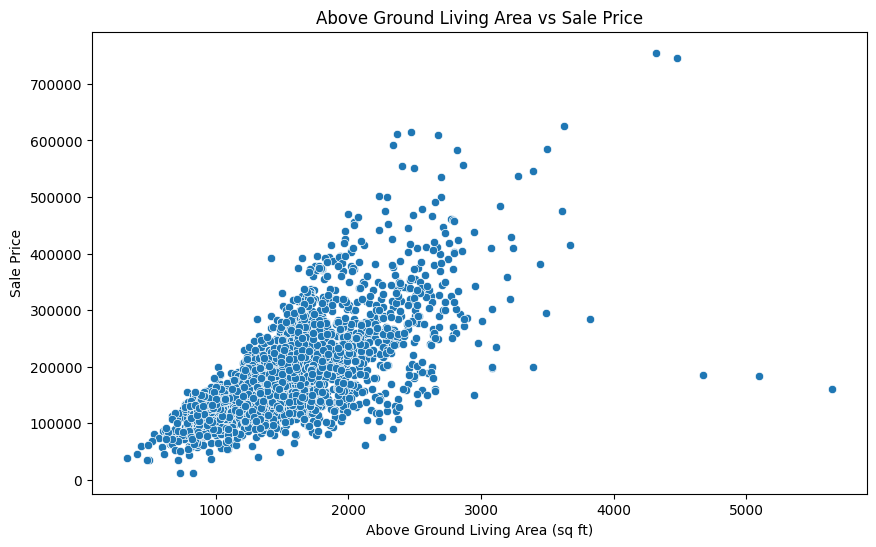

In [54]:
# Living Area vs SalePrice

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='Gr Liv Area',
    y='SalePrice'
)

plt.title('Above Ground Living Area vs Sale Price')
plt.xlabel('Above Ground Living Area (sq ft)')
plt.ylabel('Sale Price')

plt.show()

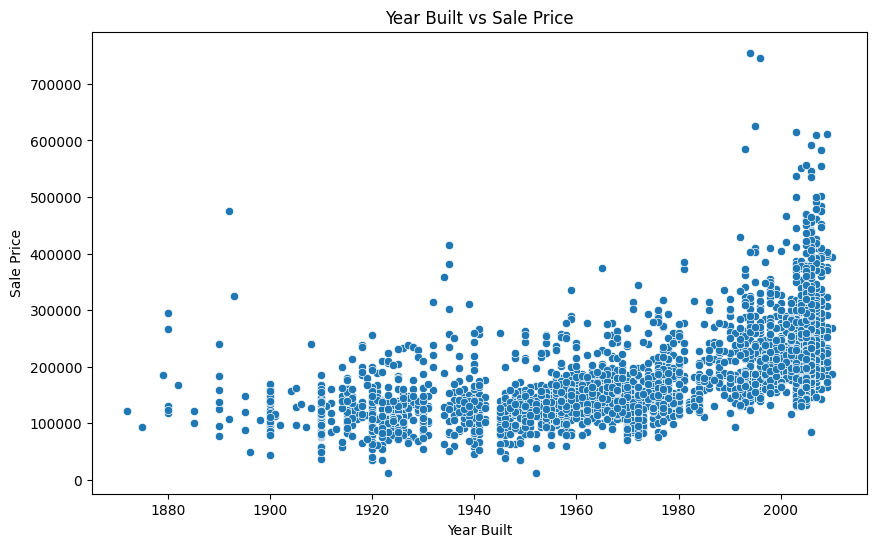

In [55]:
# Year Built vs SalePrice

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='Year Built',
    y='SalePrice'
)

plt.title('Year Built vs Sale Price')
plt.xlabel('Year Built')
plt.ylabel('Sale Price')

plt.show()

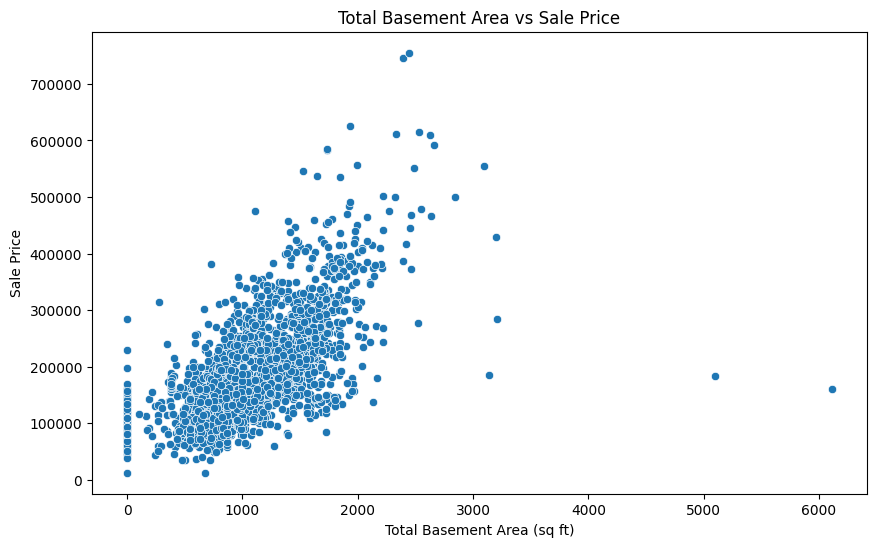

In [56]:
# Total Basement Area vs SalePrice

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='Total Bsmt SF',
    y='SalePrice'
)

plt.title('Total Basement Area vs Sale Price')
plt.xlabel('Total Basement Area (sq ft)')
plt.ylabel('Sale Price')

plt.show()

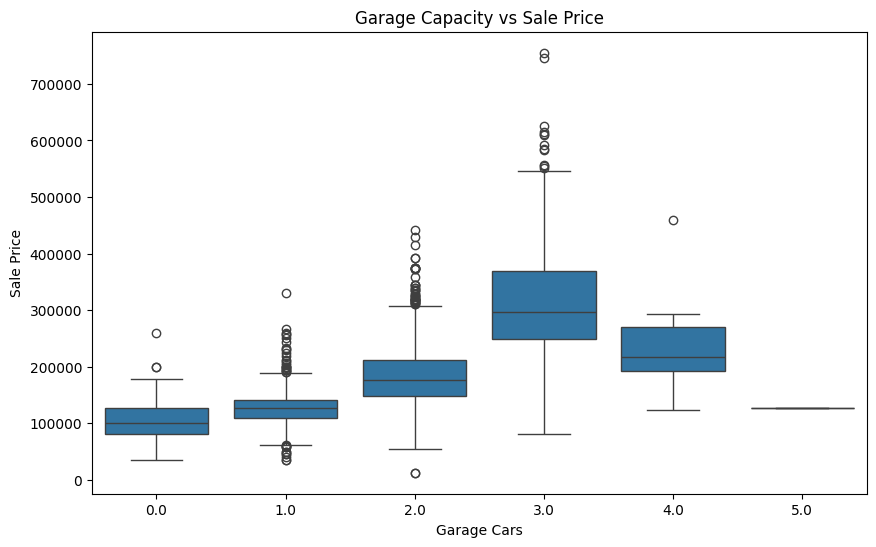

In [57]:
# Garage Capacity vs SalePrice

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x='Garage Cars',
    y='SalePrice'
)

plt.title('Garage Capacity vs Sale Price')
plt.xlabel('Garage Cars')
plt.ylabel('Sale Price')

plt.show()

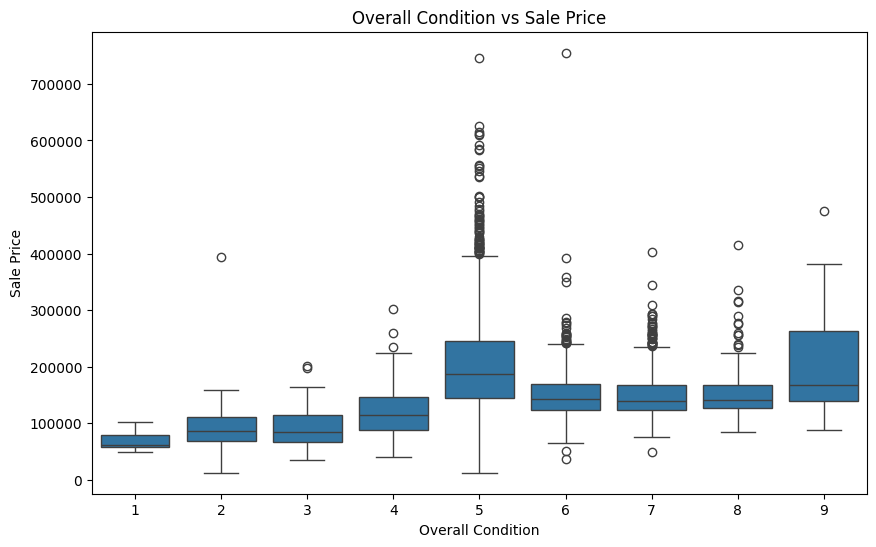

In [58]:
# Overall Condition vs SalePrice

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x='Overall Cond',
    y='SalePrice'
)

plt.title('Overall Condition vs Sale Price')
plt.xlabel('Overall Condition')
plt.ylabel('Sale Price')

plt.show()

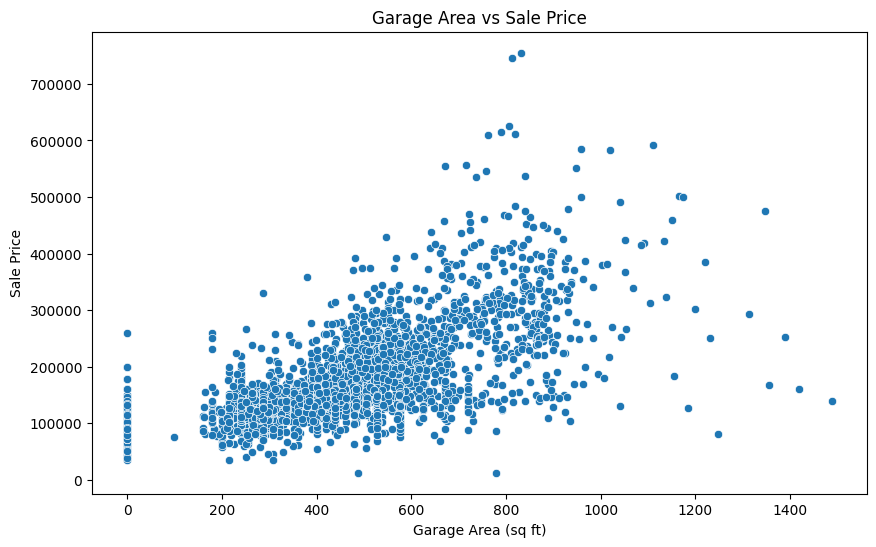

In [59]:
# Garage Area vs SalePrice

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='Garage Area',
    y='SalePrice'
)

plt.title('Garage Area vs Sale Price')
plt.xlabel('Garage Area (sq ft)')
plt.ylabel('Sale Price')

plt.show()

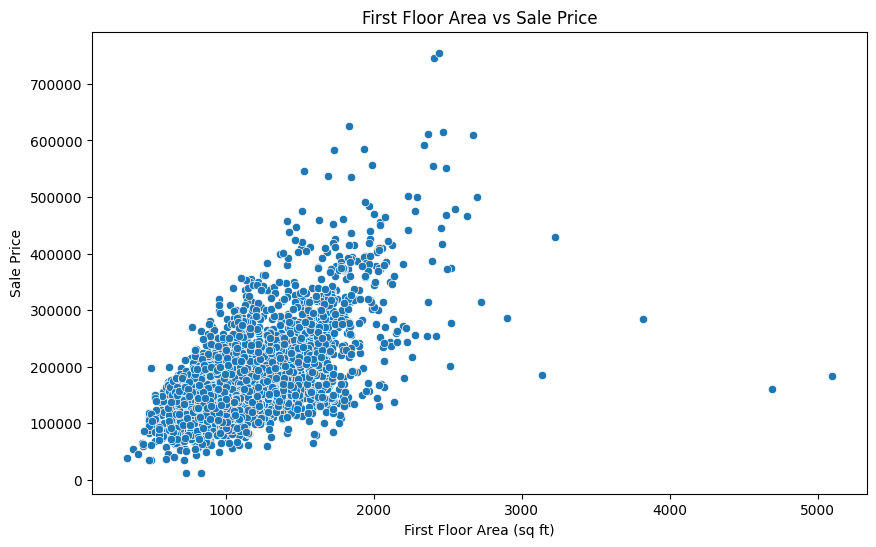

In [60]:
# First Floor Area vs SalePrice

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='1st Flr SF',
    y='SalePrice'
)

plt.title('First Floor Area vs Sale Price')
plt.xlabel('First Floor Area (sq ft)')
plt.ylabel('Sale Price')

plt.show()

 Bivariate Analysis--> Categorical Feature vs SalePrice

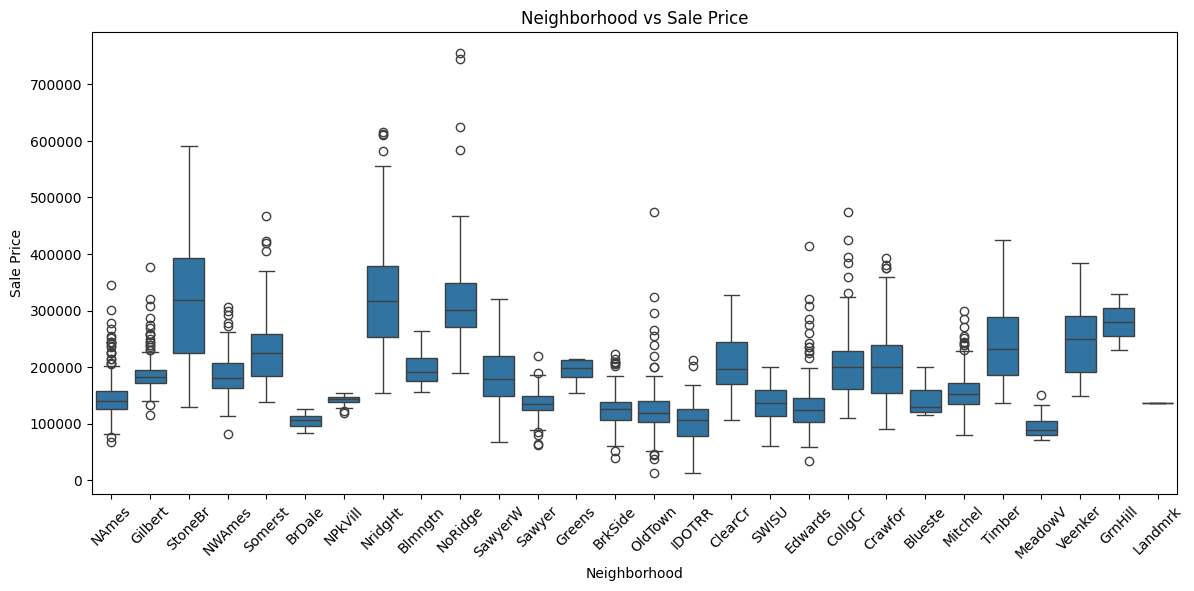

In [61]:
# 1. Neighborhood vs SalePrice

plt.figure(figsize=(14, 6))
sns.boxplot(data=df, x='Neighborhood', y='SalePrice')
plt.title('Neighborhood vs Sale Price')
plt.xlabel('Neighborhood')
plt.ylabel('Sale Price')
plt.xticks(rotation=45)
plt.show()

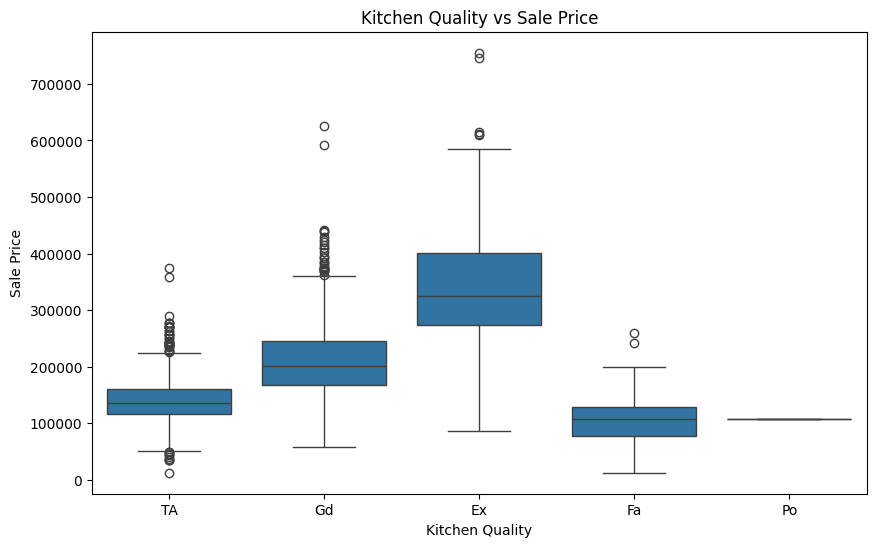

In [62]:
# 2. Kitchen Quality vs SalePrice

plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Kitchen Qual', y='SalePrice')
plt.title('Kitchen Quality vs Sale Price')
plt.xlabel('Kitchen Quality')
plt.ylabel('Sale Price')
plt.show()

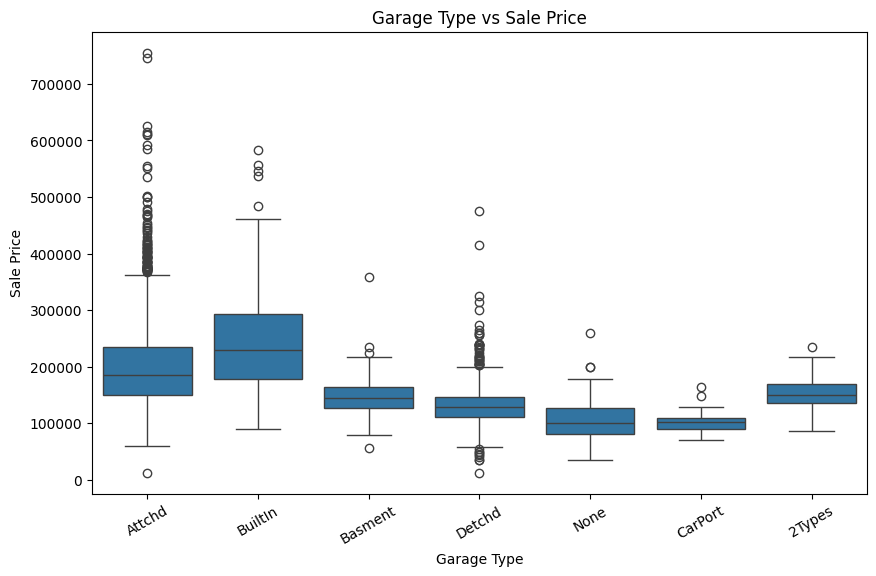

In [63]:
# 4. Garage Type vs SalePrice

plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Garage Type', y='SalePrice')
plt.title('Garage Type vs Sale Price')
plt.xlabel('Garage Type')
plt.ylabel('Sale Price')
plt.xticks(rotation=30)
plt.show()

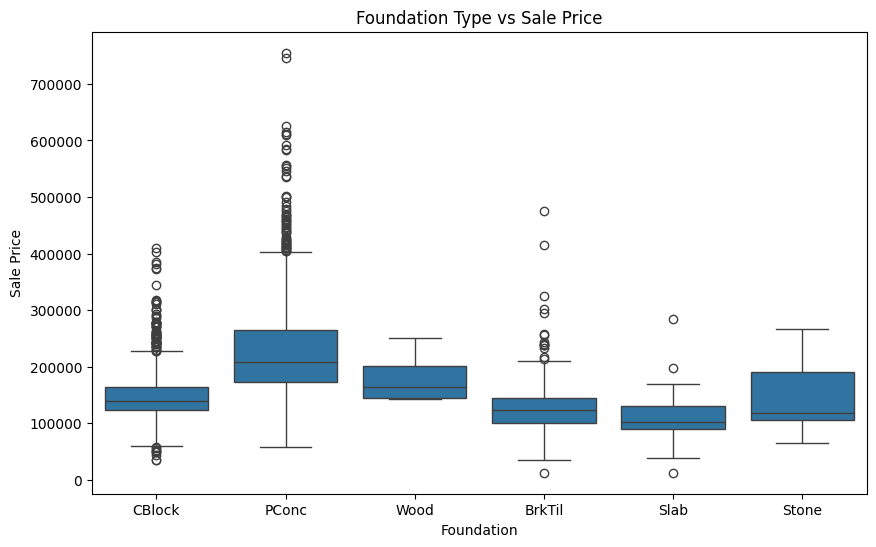

In [64]:
# 5. Foundation vs SalePrice

plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Foundation', y='SalePrice')
plt.title('Foundation Type vs Sale Price')
plt.xlabel('Foundation')
plt.ylabel('Sale Price')
plt.show()

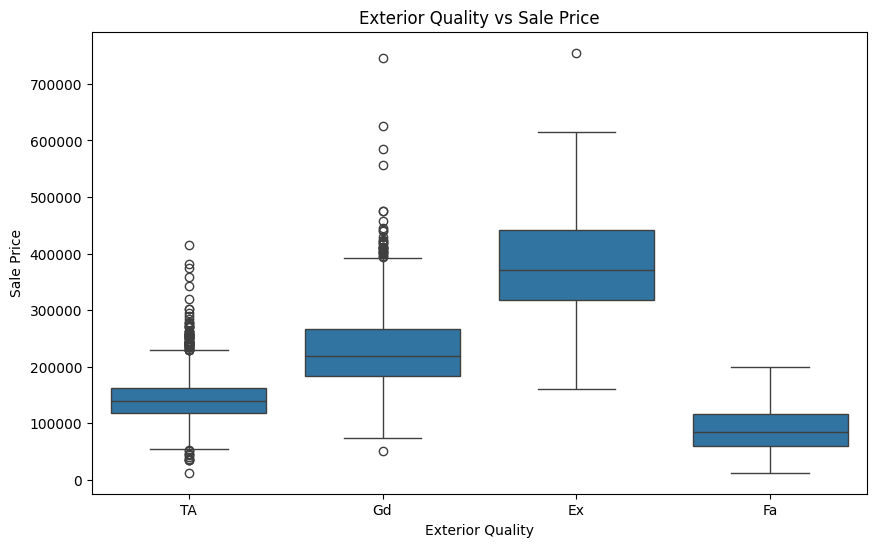

In [65]:
# 6. Exterior Quality vs SalePrice

plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Exter Qual', y='SalePrice')
plt.title('Exterior Quality vs Sale Price')
plt.xlabel('Exterior Quality')
plt.ylabel('Sale Price')
plt.show()

**Multivariate Analysis**

Multivariate Analysis-->Correlation Analysisf

In [66]:
# Select important numerical features and SalePrice
correlation = df[important_num_cols + ['SalePrice']].corr()

# Display correlation values with SalePrice
saleprice_corr = correlation['SalePrice'].sort_values(ascending=False)

saleprice_corr

,SalePrice
SalePrice,1.000000
Overall Qual,0.799262
Gr Liv Area,0.706780
Garage Cars,0.647812
Garage Area,0.640381
Total Bsmt SF,0.632164
1st Flr SF,0.621676
Year Built,0.558426
Full Bath,0.545604
Year Remod/Add,0.532974


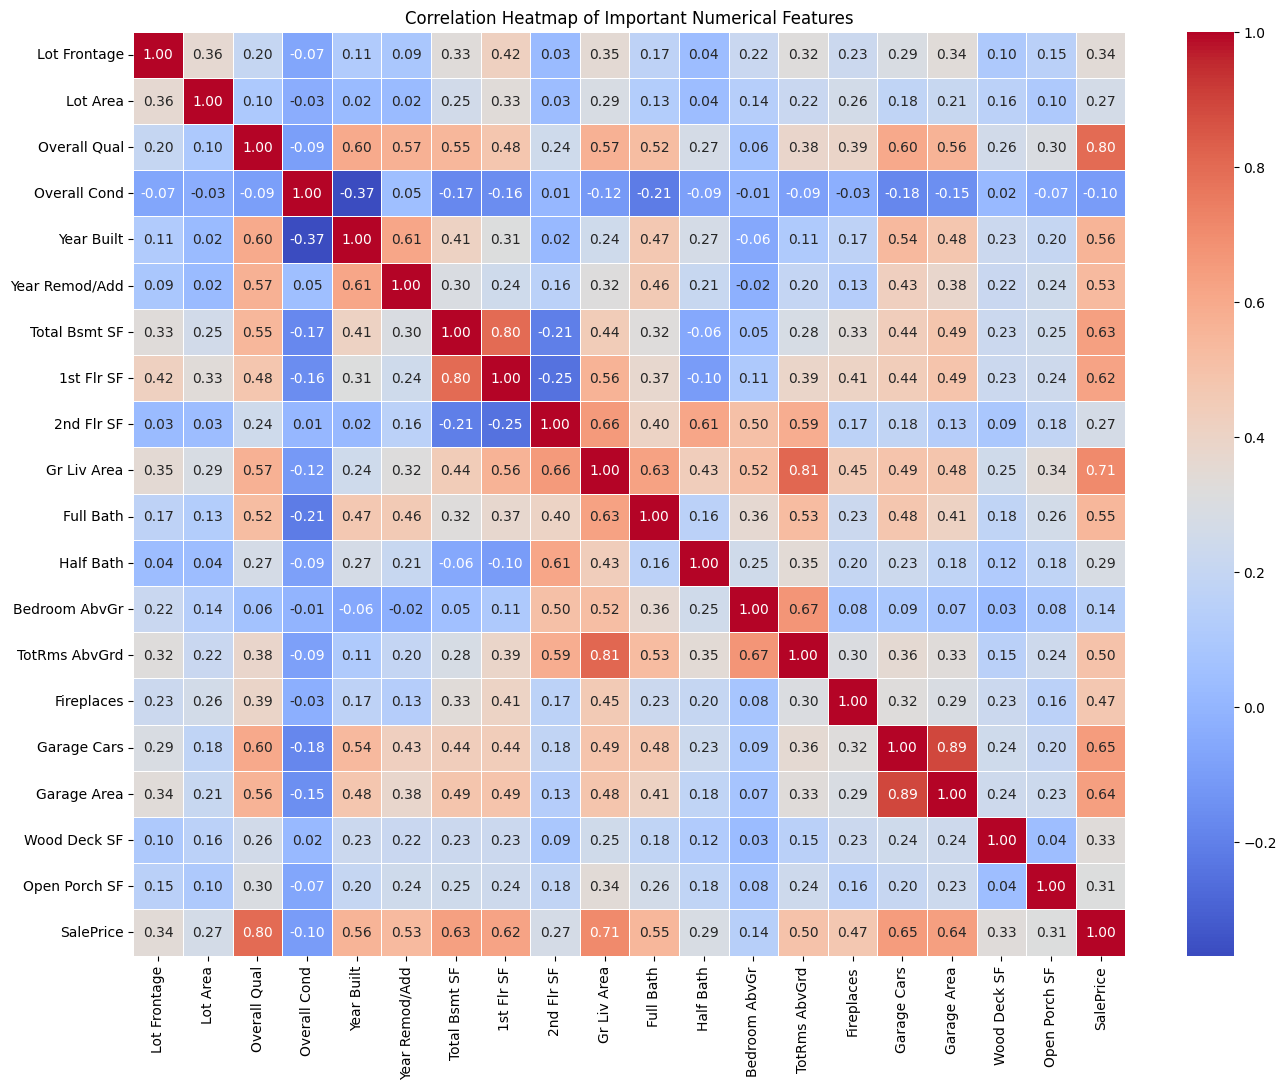

In [67]:
#Correlation Heatmap

plt.figure(figsize=(16, 12))

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)

plt.title('Correlation Heatmap of Important Numerical Features')
plt.show()

**8.Feature Engineering**

In [68]:
#Feature Engineering - House Age

df['House Age'] = df['Yr Sold'] - df['Year Built']

df[['Year Built', 'Yr Sold', 'House Age']].head()

,Year Built,Yr Sold,House Age
0,1960,2010,50
1,1961,2010,49
2,1958,2010,52
3,1968,2010,42
4,1997,2010,13


In [69]:
#Feature Engineering - Remodel Age

df['Remodel Age'] = df['Yr Sold'] - df['Year Remod/Add']

df[['Year Remod/Add', 'Yr Sold', 'Remodel Age']].head()

,Year Remod/Add,Yr Sold,Remodel Age
0,1960,2010,50
1,1961,2010,49
2,1958,2010,52
3,1968,2010,42
4,1998,2010,12


In [ ]:
#Feature Engineering - Total Living Area

df['Total Living Area'] = df['1st Flr SF'] + df['2nd Flr SF']

df[['1st Flr SF', '2nd Flr SF', 'Total Living Area']].head()

In [70]:
#Feature Engineering - Total Bathrooms

df['Total Bathrooms'] = df['Full Bath'] + (0.5 * df['Half Bath'])

df[['Full Bath', 'Half Bath', 'Total Bathrooms']].head()

,Full Bath,Half Bath,Total Bathrooms
0,1,0,1.0
1,1,0,1.0
2,1,1,1.5
3,2,1,2.5
4,2,1,2.5


**9.Data Preprocessing**

In [71]:
#Data Preprocessing - Features and Target

# Target variable
y = df['SalePrice']

# Features
X = df.drop('SalePrice', axis=1)

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (2930, 84)
Target shape: (2930,)


In [72]:
#Remove Identifier Columns

X = X.drop(['Order', 'PID'], axis=1)

print("Features shape after removing identifiers:", X.shape)

Features shape after removing identifiers: (2930, 82)


In [73]:
#Identify Numerical and Categorical Features

numerical_features = X.select_dtypes(include=np.number).columns
categorical_features = X.select_dtypes(include='object').columns

print("Number of numerical features:", len(numerical_features))
print("Number of categorical features:", len(categorical_features))

Number of numerical features: 39
Number of categorical features: 43


In [74]:
#Train-Test Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (2344, 82)
X_test: (586, 82)
y_train: (2344,)
y_test: (586,)


In [75]:
#Encoding and Scaling Setup

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

print("Preprocessor created successfully.")

Preprocessor created successfully.


**10.Regression**

Regression - Linear Regression

In [76]:
#Regression - Linear Regression

from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline

linear_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

print("Linear Regression pipeline created successfully.")

Linear Regression pipeline created successfully.


In [77]:
#Train Linear Regression Model

linear_model.fit(X_train, y_train)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


In [78]:
#Make Predictions

y_pred = linear_model.predict(X_test)

print("Predictions generated successfully.")
print("First 10 predictions:")
print(y_pred[:10])

Predictions generated successfully.
First 10 predictions:
[157332.63048415 109486.08200836 197744.43459632 135007.13426824
 132580.73345326 193107.80802831 168738.24536576 145977.84314823
  98417.67602562 363452.18930133]


Model Evaluation
  
  MAE → average absolute prediction error

  RMSE → gives more penalty to large errors
  
  R² Score → how much variation in house prices the model explains


In [79]:
#Linear Regression - Model Evaluation

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Linear Regression Performance")
print("--------------------------------")
print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")

Linear Regression Performance
--------------------------------
MAE  : 15685.10
RMSE : 29103.29
R²   : 0.8944


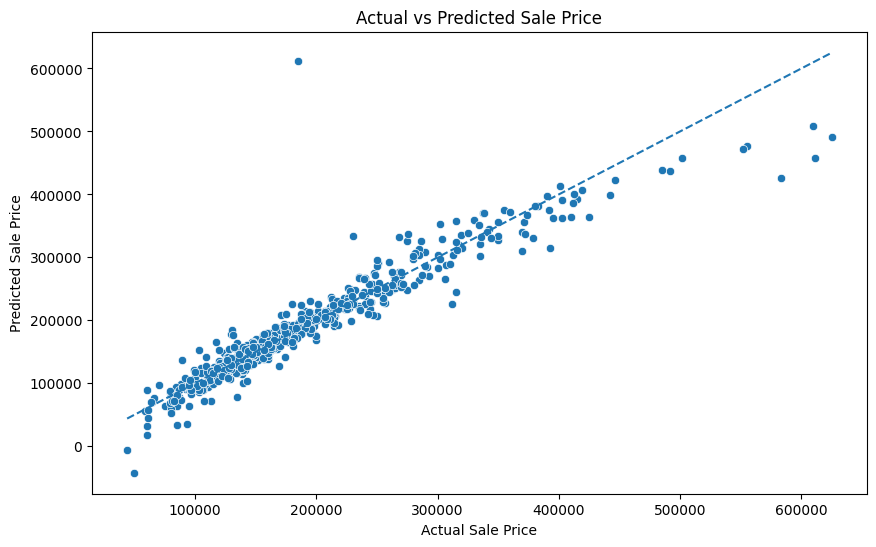

In [80]:
#Actual vs Predicted Sale Prices

plt.figure(figsize=(10, 6))

sns.scatterplot(x=y_test, y=y_pred)

plt.xlabel('Actual Sale Price')
plt.ylabel('Predicted Sale Price')
plt.title('Actual vs Predicted Sale Price')

# Perfect prediction reference line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle='--'
)

plt.show()

 Regression - Random Forest Regression

In [81]:
#Random Forest Regression

from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline

rf_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ))
])

print("Random Forest Regression pipeline created successfully.")

Random Forest Regression pipeline created successfully.


In [82]:
#Train Random Forest Model

rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [83]:
#Make Predictions

rf_pred = rf_model.predict(X_test)

print("Predictions generated successfully.")
print("First 10 predictions:")
print(rf_pred[:10])

Predictions generated successfully.
First 10 predictions:
[188218.305 103209.25  192939.975 115793.915 111029.25  178016.455
 166224.57  148113.75   88013.715 359682.985]


In [84]:
#Random Forest - Model Evaluation

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest Regression Performance")
print("--------------------------------------")
print(f"MAE  : {rf_mae:.2f}")
print(f"RMSE : {rf_rmse:.2f}")
print(f"R²   : {rf_r2:.4f}")

Random Forest Regression Performance
--------------------------------------
MAE  : 15612.76
RMSE : 26381.37
R²   : 0.9132


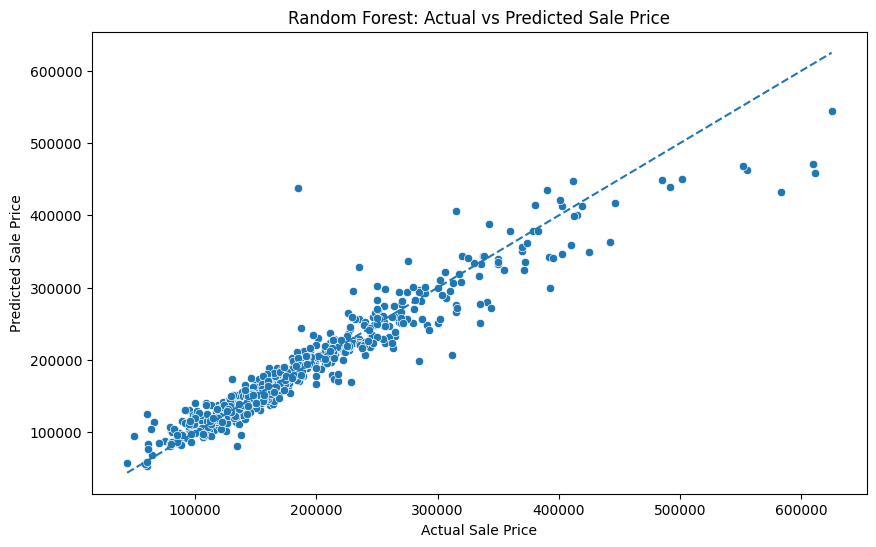

In [85]:
#Actual vs Predicted - Random Forest

plt.figure(figsize=(10, 6))

sns.scatterplot(x=y_test, y=rf_pred)

plt.xlabel('Actual Sale Price')
plt.ylabel('Predicted Sale Price')
plt.title('Random Forest: Actual vs Predicted Sale Price')

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle='--'
)

plt.show()

**11. K-Means Clustering – Property Segmentation.**

In [88]:
# Recreate Total Living Area

df['Total Living Area'] = df['1st Flr SF'] + df['2nd Flr SF']

print("Total Living Area created successfully.")

Total Living Area created successfully.


In [89]:
df[['1st Flr SF', '2nd Flr SF', 'Total Living Area']].head()

,1st Flr SF,2nd Flr SF,Total Living Area
0,1656,0,1656
1,896,0,896
2,1329,0,1329
3,2110,0,2110
4,928,701,1629


In [90]:
df[['House Age', 'Remodel Age', 'Total Living Area', 'Total Bathrooms']].head()

,House Age,Remodel Age,Total Living Area,Total Bathrooms
0,50,50,1656,1.0
1,49,49,896,1.0
2,52,52,1329,1.5
3,42,42,2110,2.5
4,13,12,1629,2.5


In [91]:
#Select K-Means Features

kmeans_features = [
    'Overall Qual',
    'Overall Cond',
    'Year Built',
    'Gr Liv Area',
    'Total Bsmt SF',
    '1st Flr SF',
    '2nd Flr SF',
    'Garage Cars',
    'Garage Area',
    'Total Living Area',
    'Total Bathrooms',
    'House Age',
    'Remodel Age'
]

X_kmeans = df[kmeans_features].copy()

print("K-Means dataset shape:", X_kmeans.shape)

X_kmeans.head()

K-Means dataset shape: (2930, 13)


,Overall Qual,Overall Cond,Year Built,Gr Liv Area,Total Bsmt SF,1st Flr SF,2nd Flr SF,Garage Cars,Garage Area,Total Living Area,Total Bathrooms,House Age,Remodel Age
0,6,5,1960,1656,1080.0,1656,0,2.0,528.0,1656,1.0,50,50
1,5,6,1961,896,882.0,896,0,1.0,730.0,896,1.0,49,49
2,6,6,1958,1329,1329.0,1329,0,1.0,312.0,1329,1.5,52,52
3,7,5,1968,2110,2110.0,2110,0,2.0,522.0,2110,2.5,42,42
4,5,5,1997,1629,928.0,928,701,2.0,482.0,1629,2.5,13,12


In [92]:
#Scale the Features

from sklearn.preprocessing import StandardScaler

scaler_kmeans = StandardScaler()

X_kmeans_scaled = scaler_kmeans.fit_transform(X_kmeans)

print("Scaled data shape:", X_kmeans_scaled.shape)

Scaled data shape: (2930, 13)


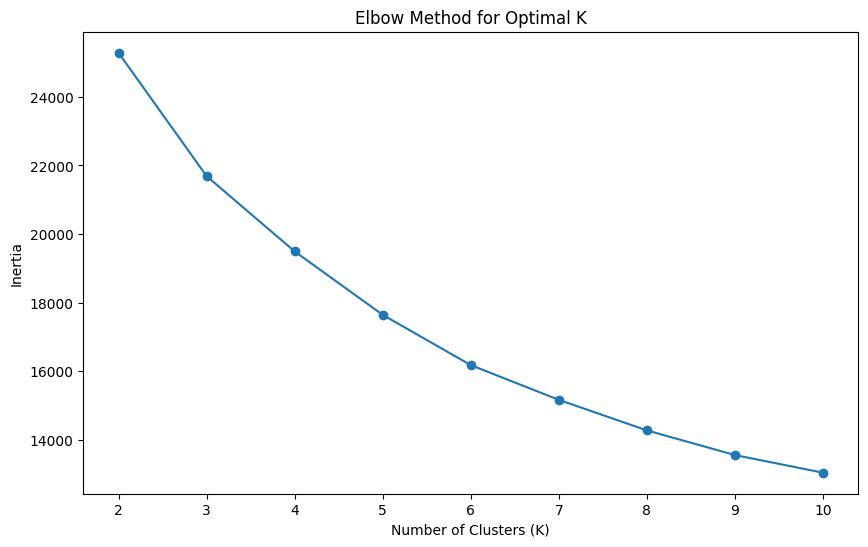

In [93]:
#Elbow Method
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_kmeans_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(range(2, 11), inertia, marker='o')

plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal K')
plt.xticks(range(2, 11))
plt.show()

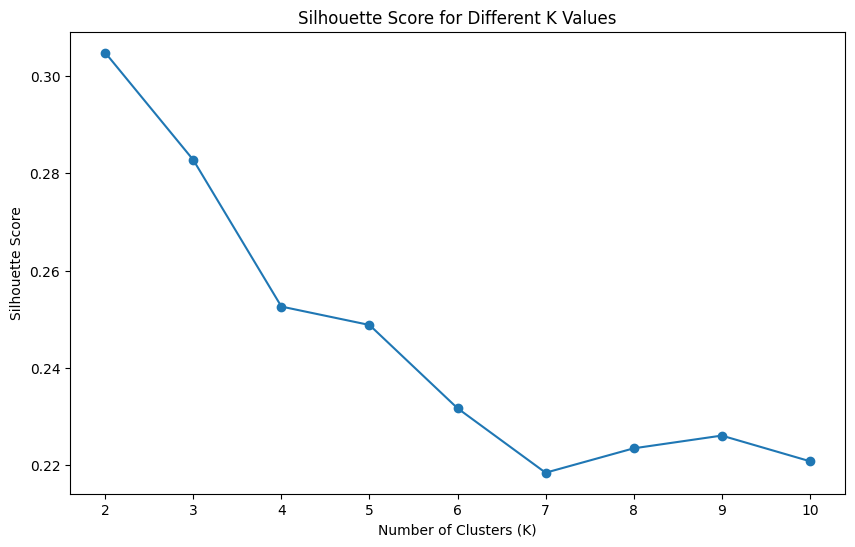

In [94]:
#Silhouette Score
from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    cluster_labels = kmeans.fit_predict(X_kmeans_scaled)

    score = silhouette_score(X_kmeans_scaled, cluster_labels)
    silhouette_scores.append(score)

plt.figure(figsize=(10, 6))
plt.plot(range(2, 11), silhouette_scores, marker='o')

plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for Different K Values')
plt.xticks(range(2, 11))
plt.show()

In [95]:
#Train Final K-Means

from sklearn.cluster import KMeans

# Set the optimal number of clusters
optimal_k = 3

kmeans_final = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

# Create cluster labels
df['KMeans_Cluster'] = kmeans_final.fit_predict(X_kmeans_scaled)

print("K-Means clustering completed!")


K-Means clustering completed!


In [96]:
#Check Cluster Distribution
df['KMeans_Cluster'].value_counts().sort_index()

,count
KMeans_Cluster,
0,716
1,1468
2,746


In [97]:
#View Cluster Profiles
cluster_profile = df.groupby('KMeans_Cluster')[kmeans_features].mean()

cluster_profile

,Overall Qual,Overall Cond,Year Built,Gr Liv Area,Total Bsmt SF,1st Flr SF,2nd Flr SF,Garage Cars,Garage Area,Total Living Area,Total Bathrooms,House Age,Remodel Age
KMeans_Cluster,,,,,,,,,,,,,
0,6.923184,5.329609,1990.061453,1994.988827,958.850559,1062.282123,928.164804,2.208101,566.861732,1990.446927,2.525838,17.685754,11.709497
1,5.137602,5.869891,1950.425749,1201.917575,851.001362,986.035422,208.762943,1.285422,352.547003,1194.798365,1.273501,57.387602,35.777248
2,7.183646,5.183646,1994.591153,1610.276139,1535.337802,1594.383378,15.892761,2.290885,619.245308,1610.276139,1.967828,13.195710,10.750670


In [98]:
#K-Means Cluster Visualization using PCA

from sklearn.decomposition import PCA

# Reduce the 13 features to 2 dimensions
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_kmeans_scaled)

print("PCA shape:", X_pca.shape)

PCA shape: (2930, 2)


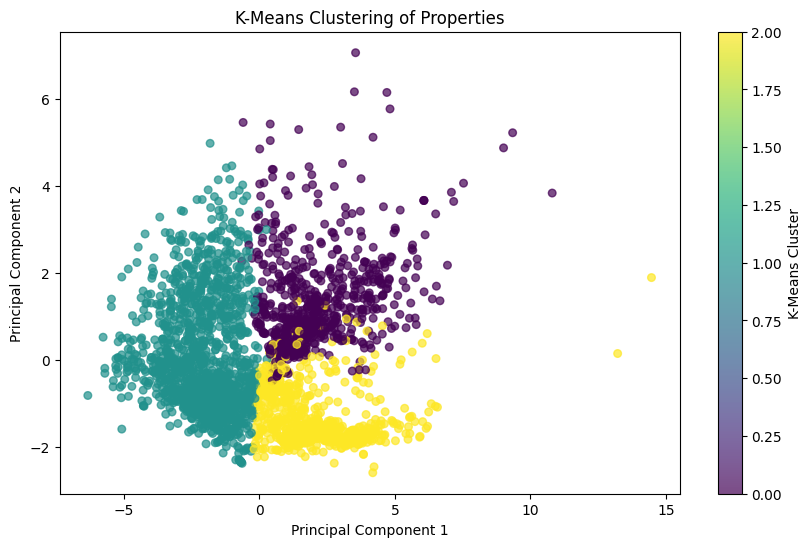

In [99]:
# K-Means Cluster Visualization using PCA

plt.figure(figsize=(10, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=df['KMeans_Cluster'],
    cmap='viridis',
    s=30,
    alpha=0.7
)

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('K-Means Clustering of Properties')
plt.colorbar(label='K-Means Cluster')

plt.show()

**11.DBSCAN Clustering**

In [100]:
# DBSCAN Clustering

from sklearn.cluster import DBSCAN

X_dbscan = X_kmeans_scaled.copy()

print("DBSCAN dataset shape:", X_dbscan.shape)

DBSCAN dataset shape: (2930, 13)


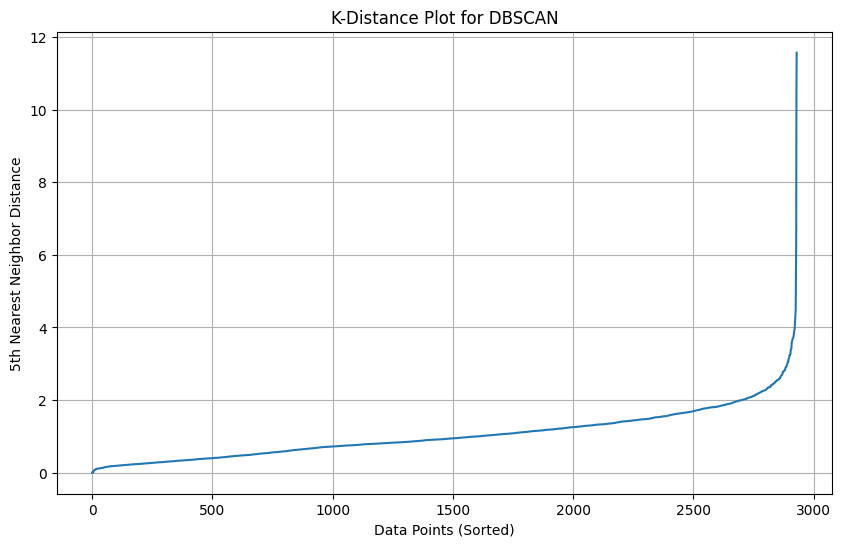

In [101]:
# K-Distance Plot for DBSCAN

from sklearn.neighbors import NearestNeighbors
import numpy as np
import matplotlib.pyplot as plt

# Set min_samples
min_samples = 5

# Find distances to the 5th nearest neighbor
neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors_fit = neighbors.fit(X_dbscan)

distances, indices = neighbors_fit.kneighbors(X_dbscan)

# Sort the distances
k_distances = np.sort(distances[:, min_samples - 1])

# Plot
plt.figure(figsize=(10, 6))

plt.plot(k_distances)

plt.xlabel('Data Points (Sorted)')
plt.ylabel('5th Nearest Neighbor Distance')
plt.title('K-Distance Plot for DBSCAN')

plt.grid(True)
plt.show()

In [102]:
# Test Different DBSCAN eps Values

from sklearn.cluster import DBSCAN
import pandas as pd

eps_values = [1.0, 1.2, 1.4, 1.6, 1.8, 2.0]

dbscan_results = []

for eps in eps_values:
    dbscan = DBSCAN(
        eps=eps,
        min_samples=5
    )

    labels = dbscan.fit_predict(X_dbscan)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)

    dbscan_results.append({
        'eps': eps,
        'Clusters': n_clusters,
        'Noise Points': n_noise
    })

dbscan_results = pd.DataFrame(dbscan_results)

dbscan_results

,eps,Clusters,Noise Points
0,1.0,24,1095
1,1.2,15,766
2,1.4,10,504
3,1.6,6,339
4,1.8,2,200
5,2.0,1,130


In [103]:
# Final DBSCAN Clustering

dbscan_final = DBSCAN(
    eps=1.6,
    min_samples=5
)

df['DBSCAN_Cluster'] = dbscan_final.fit_predict(X_dbscan)

print("DBSCAN clustering completed!")

DBSCAN clustering completed!


In [104]:
# DBSCAN Cluster Distribution

df['DBSCAN_Cluster'].value_counts().sort_index()

,count
DBSCAN_Cluster,
-1,339
0,2546
1,14
2,7
3,4
4,6
5,14


In [105]:
# DBSCAN Cluster Distribution

dbscan_counts = df['DBSCAN_Cluster'].value_counts().sort_index()

print("DBSCAN Cluster Distribution:")
print(dbscan_counts)

DBSCAN Cluster Distribution:
DBSCAN_Cluster
-1     339
 0    2546
 1      14
 2       7
 3       4
 4       6
 5      14
Name: count, dtype: int64


In [106]:
# Number of Clusters and Noise Points

n_clusters = len(set(df['DBSCAN_Cluster'])) - (
    1 if -1 in df['DBSCAN_Cluster'].values else 0
)

n_noise = (df['DBSCAN_Cluster'] == -1).sum()

print("Number of Clusters:", n_clusters)
print("Number of Noise Points:", n_noise)

Number of Clusters: 6
Number of Noise Points: 339


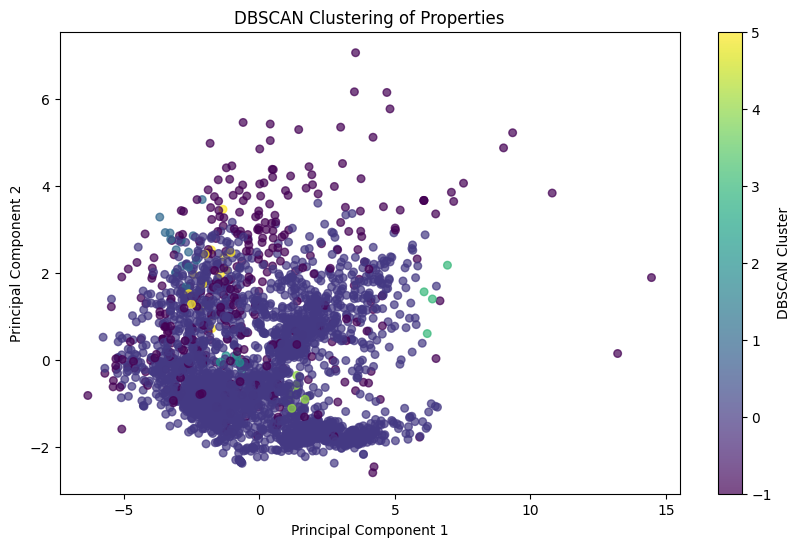

In [107]:
# DBSCAN Cluster Visualization using PCA

plt.figure(figsize=(10, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=df['DBSCAN_Cluster'],
    cmap='viridis',
    s=30,
    alpha=0.7
)

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('DBSCAN Clustering of Properties')
plt.colorbar(label='DBSCAN Cluster')

plt.show()

In [108]:
# Regression Model Comparison

regression_results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'MAE': [15685.10, 15612.76],
    'RMSE': [29103.29, 26381.37],
    'R2 Score': [0.8944, 0.9132]
})

regression_results

,Model,MAE,RMSE,R2 Score
0,Linear Regression,15685.10,29103.29,0.8944
1,Random Forest,15612.76,26381.37,0.9132


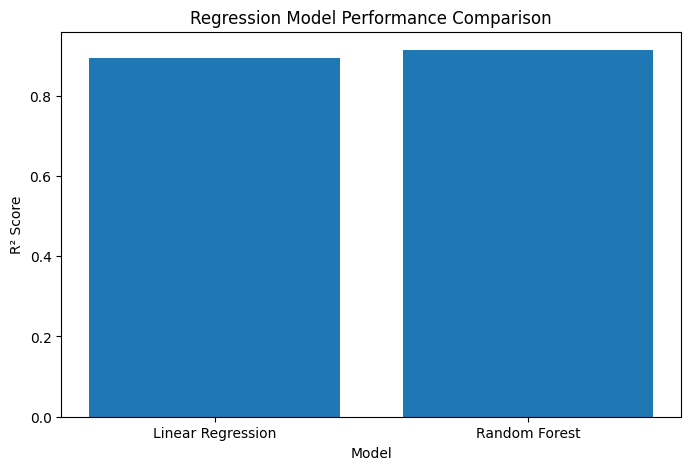

In [109]:
# R² Score Comparison

plt.figure(figsize=(8, 5))

plt.bar(
    regression_results['Model'],
    regression_results['R2 Score']
)

plt.xlabel('Model')
plt.ylabel('R² Score')
plt.title('Regression Model Performance Comparison')

plt.show()

In [110]:
# K-Means Cluster Summary

kmeans_summary = df.groupby('KMeans_Cluster')[kmeans_features].mean()

kmeans_summary

,Overall Qual,Overall Cond,Year Built,Gr Liv Area,Total Bsmt SF,1st Flr SF,2nd Flr SF,Garage Cars,Garage Area,Total Living Area,Total Bathrooms,House Age,Remodel Age
KMeans_Cluster,,,,,,,,,,,,,
0,6.923184,5.329609,1990.061453,1994.988827,958.850559,1062.282123,928.164804,2.208101,566.861732,1990.446927,2.525838,17.685754,11.709497
1,5.137602,5.869891,1950.425749,1201.917575,851.001362,986.035422,208.762943,1.285422,352.547003,1194.798365,1.273501,57.387602,35.777248
2,7.183646,5.183646,1994.591153,1610.276139,1535.337802,1594.383378,15.892761,2.290885,619.245308,1610.276139,1.967828,13.195710,10.750670


In [111]:
# K-Means Cluster Sizes

kmeans_cluster_size = df['KMeans_Cluster'].value_counts().sort_index()

print("K-Means Cluster Sizes:")
print(kmeans_cluster_size)

K-Means Cluster Sizes:
KMeans_Cluster
0     716
1    1468
2     746
Name: count, dtype: int64


In [112]:
# DBSCAN Cluster Sizes

dbscan_summary = df['DBSCAN_Cluster'].value_counts().sort_index()

print("DBSCAN Cluster Sizes:")
print(dbscan_summary)

DBSCAN Cluster Sizes:
DBSCAN_Cluster
-1     339
 0    2546
 1      14
 2       7
 3       4
 4       6
 5      14
Name: count, dtype: int64


In [113]:
# DBSCAN Noise Percentage

noise_points = (df['DBSCAN_Cluster'] == -1).sum()
total_points = len(df)

noise_percentage = (noise_points / total_points) * 100

print("Noise Points:", noise_points)
print("Noise Percentage:", round(noise_percentage, 2), "%")

Noise Points: 339
Noise Percentage: 11.57 %


In [114]:
# Overall Project Summary

print("🏠 HOUSE PRICE PREDICTION & PROPERTY SEGMENTATION")
print("=" * 55)

print("\n📈 REGRESSION")
print("-" * 55)
print("Linear Regression  → R²: 0.8944")
print("Random Forest      → R²: 0.9132")

print("\n🔵 K-MEANS CLUSTERING")
print("-" * 55)
print("Number of Clusters →", df['KMeans_Cluster'].nunique())

print("\n🟣 DBSCAN CLUSTERING")
print("-" * 55)
print("Number of Clusters →", n_clusters)
print("Noise Points       →", n_noise)
print("Noise Percentage   →", round(noise_percentage, 2), "%")

🏠 HOUSE PRICE PREDICTION & PROPERTY SEGMENTATION

📈 REGRESSION
-------------------------------------------------------
Linear Regression  → R²: 0.8944
Random Forest      → R²: 0.9132

🔵 K-MEANS CLUSTERING
-------------------------------------------------------
Number of Clusters → 3

🟣 DBSCAN CLUSTERING
-------------------------------------------------------
Number of Clusters → 6
Noise Points       → 339
Noise Percentage   → 11.57 %


**Conclusion**

  This project applied multiple machine learning techniques to analyze the Ames Housing dataset and understand residential property prices and segments.

**Regression**

  Linear Regression and Random Forest were used to predict house sale prices. Random Forest achieved an R² score of 0.9132, while Linear Regression achieved an R² score of 0.8944.

**K-Means Clustering**

  K-Means was used to segment properties based on characteristics such as quality, living area, garage capacity, bathrooms, and property age. The analysis identified three distinct property segments with different combinations of size, quality, and age.

**DBSCAN Clustering**

  DBSCAN was applied to identify density-based property groups and detect observations that did not belong to dense clusters. The noise points identified by DBSCAN can represent properties with unusual combinations of characteristics.

**Key Insights**

  - Property quality and size are important factors associated with house prices.
  - Newer and higher-quality properties generally form different segments from older and smaller properties.
  - Random Forest captured nonlinear relationships between property characteristics and sale prices.
  - Clustering provided an additional perspective by grouping properties based on their characteristics rather than their sale prices.

**Overall Outcome**

  The project demonstrates how regression and clustering techniques can be combined to understand house prices, identify property segments, and detect unusual property patterns using machine learning.